### Chuẩn bị thư viện

In [109]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import lightgbm as lgb
import matplotlib.pyplot as plt

### Chuẩn bị dữ liệu

In [110]:
# Lấy về dữ liệu train và test
url_train = "C:/Users/Hi Windows 11 Home/Downloads/clean_log_jul95.parquet"
url_test = "C:/Users/Hi Windows 11 Home/Downloads/output_test.parquet"

data_train = pd.read_parquet(url_train)
data_test = pd.read_parquet(url_test)

### Xử lý benchmark

In [111]:
def build_request_rate(df, window=WINDOW):
    rate_df = (
        df
        .set_index("timestamp")
        .resample(window)
        .size()
        .rename("request_rate")
        .reset_index()
    )
    
    return rate_df

### Xây dựng feature

In [112]:
def build_features(rate_df):
    df = rate_df.sort_values("timestamp").reset_index(drop=True)

    y = df["request_rate"]

    # Lag features (phút)
    for lag in [1, 2, 3, 5,10]:
        df[f"lag_{lag}"] = y.shift(lag)

    # Rolling statistics (dùng quá khứ)
    for win in [3, 5]:
        df[f"roll_mean_{win}"] = y.shift(1).rolling(win).mean()
        df[f"roll_std_{win}"]  = y.shift(1).rolling(win).std()
        df[f"roll_max_{win}"]  = y.shift(1).rolling(win).max()

    # Local dynamics
    df["diff_1"] = y.shift(1) - y.shift(2)
    df["abs_diff_1"] = df["diff_1"].abs()

    # Time encoding
    df["hour"] = df["timestamp"].dt.hour
    df["minute"] = df["timestamp"].dt.minute

    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    # Drop invalid rows
    df = df.dropna().reset_index(drop=True)

    X = df.drop(columns=["timestamp", "request_rate"])
    y = df["request_rate"]

    return X, y, df


### Model

In [113]:
def build_model(dtrain, dtest):
    model = lgb.LGBMRegressor(
        objective="regression",
        learning_rate=0.05,
        num_leaves=63,
        max_depth=7,
        min_data_in_leaf=100,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        lambda_l2=5,
        n_estimators=300,
        random_state=42
    )
    model.fit(dtrain, dtest)
    return model

### Đánh giá chỉ số

In [114]:
def evaluate(y_true, y_pred, eps=1e-8, as_table=True):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = np.abs(y_true) > eps

    metrics = {
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MAPE": (
            mean_absolute_percentage_error(y_true[mask], y_pred[mask])
            if mask.any() else np.nan
        )
    }

    if as_table:
        return pd.DataFrame(
            metrics.values(),
            index=metrics.keys(),
            columns=["Value"]
        )

    return metrics

### Feature Importance

In [115]:
def feature_importance(model):
    return lgb.plot_importance(model, xlabel='importance', ylabel='Features')

In [116]:
def plot_lgbm_actual_vs_pred(
    df_test,
    X_test,
    model,
    target_col="request_rate",
    time_col="timestamp",
    figsize=(14, 3)
    ):
    
    ts = df_test[time_col].values
    y_true = df_test[target_col].values
    y_pred = model.predict(X_test)

    plt.figure(figsize=figsize)
    plt.plot(ts, y_true, label="Actual")
    plt.plot(ts, y_pred, label="LightGBM prediction")
    plt.legend()
    plt.title("LightGBM: Actual vs Prediction")
    plt.xlabel("Time")
    plt.ylabel("Request rate")
    plt.tight_layout()
    plt.show()

### Pipeline thực thi

In [117]:
def pipeline_impl(raw_train, raw_test, w):
    
    # Chuyển dữ liệu về request
    WINDOW = w
    train_rate = build_request_rate(data_train, WINDOW)
    test_rate = build_request_rate(data_test, WINDOW)

    # Feature Engineering
    X_train, y_train, train_feat_df = build_features(train_rate)
    X_test,  y_test,  test_feat_df  = build_features(test_rate)


    # Huấn luyện model
    lgbm = build_model(X_train, y_train)
    y_pred = lgbm.predict(X_test)

    # Đánh giá model
    df_metrics = evaluate(y_test, y_pred, as_table = True)
    print(df_metrics)
    # Feature importance
    feature_importance(lgbm)

    plot_lgbm_actual_vs_pred(
        df_test=test_feat_df,
        X_test=X_test,
        model=lgbm
    )

### Benchmark 1m

[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored

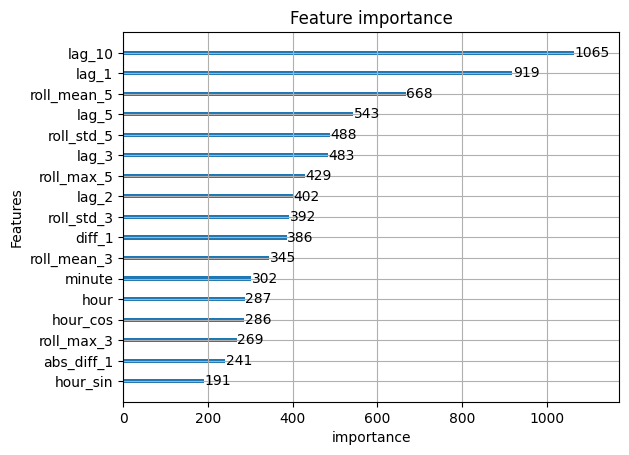

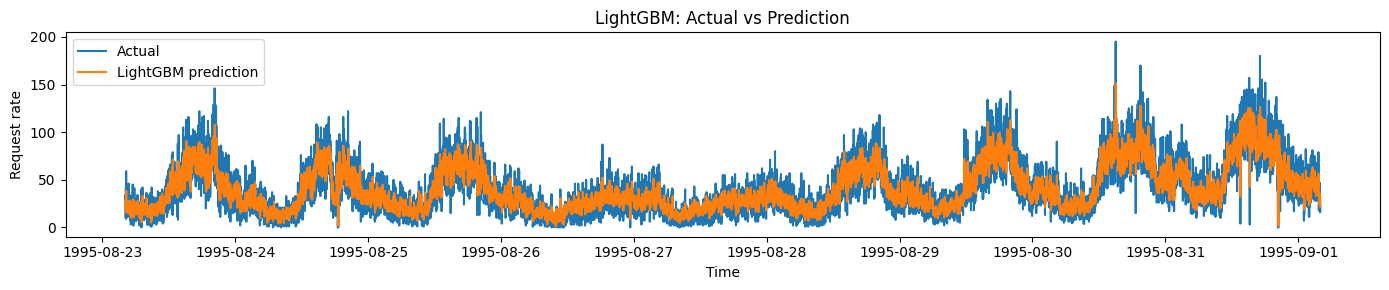

In [118]:
pipeline_impl(data_train, data_test, w='1min')

### Benchmark 5m

[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored

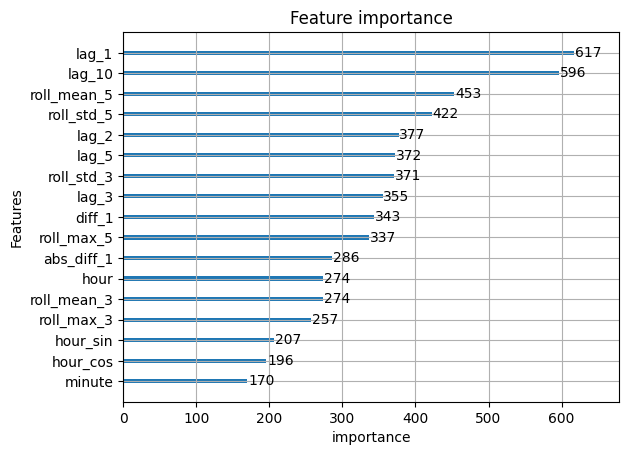

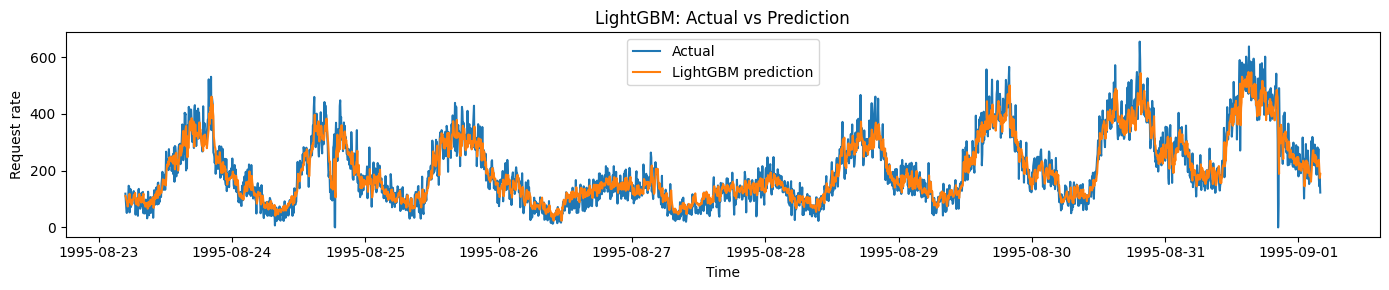

In [120]:
pipeline_impl(data_train, data_test, w='5min')

### Benchmark 15m

[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored

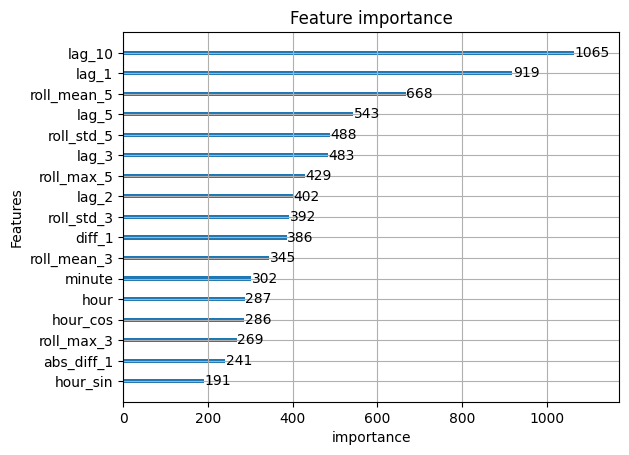

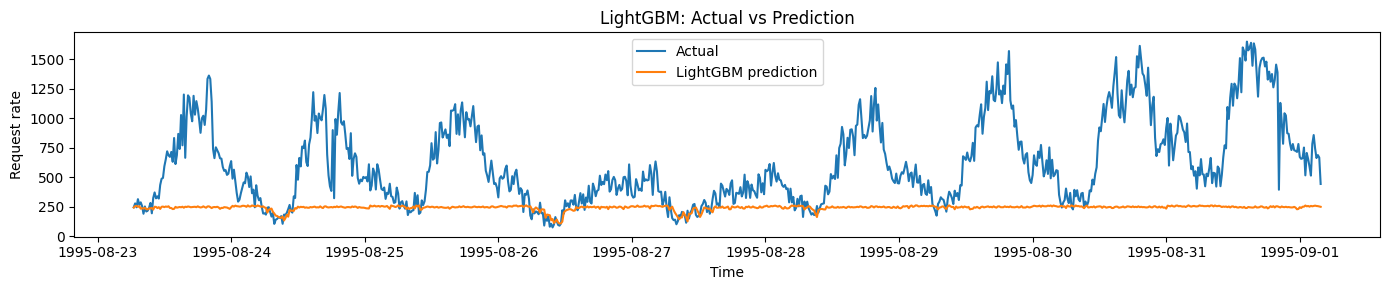

In [106]:
pipeline_impl(data_train, data_test, w='15min')